# Random Forest - BODMAS Malware Classification

Random Forest was selected as the second classifier for the following reasons:

- **Non-linear decision boundaries:** PE binary feature spaces contain complex, non-linear relationships between features that Logistic Regression cannot capture. Random Forest handles these naturally through deep tree splits.
- **No feature scaling required:** Unlike gradient-based methods, Random Forest is invariant to feature scale, so `StandardScaler` is not needed in the pipeline.
- **Robustness to noise and irrelevant features:** Bagging and random feature subsampling at each split (`max_features='sqrt'`) make Random Forest robust to noisy or redundant features, which are common in PE feature extraction.
- **Class imbalance:** `class_weight='balanced_subsample'` reweights classes within each bootstrap sample, which is more appropriate than global balancing for an ensemble method.
- **Strong empirical baseline:** Random Forest consistently performs well on tabular malware classification tasks and provides feature importance as a bonus interpretability tool.

In [ ]:
# ============================================================
# RANDOM FOREST NOTEBOOK
# ============================================================

import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

from google.colab import drive
drive.mount('/content/drive')

# =========================
# MAIN PROJECT PATH
# =========================
PROJECT_DIR = "/content/drive/MyDrive/BODMAS_Assignment_Final/Latest_retrain"

# Main original dataset folder.
DATA_DIR = os.path.join(PROJECT_DIR, "dataset")

# Newly released holdout dataset folder
HOLDOUT_DIR = os.path.join(PROJECT_DIR, "HoldOutDataSet")

OUTPUT_DIR = os.path.join(PROJECT_DIR, "randomforest")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Original feature dataset used to extract the 100,000 official training rows.
BODMAS_NPZ = os.path.join(DATA_DIR, "bodmas.npz")

# Original metadata is used only to map SHA -> row index in bodmas.npz.
ORIGINAL_METADATA_CSV = os.path.join(DATA_DIR, "bodmas_metadata.csv")

# Official retraining subset metadata released with the holdout dataset.
TRAIN_TEST_METADATA_CSV = os.path.join(HOLDOUT_DIR, "bodmas_metadata_train_test.csv")

# Same malware category file released with the holdout dataset.
CATEGORY_CSV = os.path.join(HOLDOUT_DIR, "bodmas_malware_category.csv")

# Holdout files for final evaluation.
HOLDOUT_NPZ = os.path.join(HOLDOUT_DIR, "bodmas_holdout.npz")
HOLDOUT_METADATA_CSV = os.path.join(HOLDOUT_DIR, "bodmas_metadata_holdout.csv")

RANDOM_STATE = 42
TEST_SIZE = 0.20   # for internal validation only

print("Original data folder:", DATA_DIR)
print("Holdout/retraining folder:", HOLDOUT_DIR)
print("Random Forest output folder:", OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original data folder: /content/drive/MyDrive/BODMAS_Assignment_Final/Latest_retrain/dataset
Holdout/retraining folder: /content/drive/MyDrive/BODMAS_Assignment_Final/Latest_retrain/HoldOutDataSet
Random Forest output folder: /content/drive/MyDrive/BODMAS_Assignment_Final/Latest_retrain/randomforest


## Data Loading

The BODMAS dataset consists of three files:
- `bodmas.npz` - the pre-extracted numerical feature matrix `X`
- `bodmas_metadata.csv` - SHA256 hashes and file-level metadata for all samples
- `bodmas_malware_category.csv` - maps SHA256 hashes to malware family labels (malware only)

These are loaded separately and joined on the SHA256 column in the next step.

## Label Preparation

Labels are assigned by joining metadata with the category file on SHA256. Samples absent from the category file are benign by definition and are filled accordingly. The SHA column name is auto-detected to handle schema differences.

In [ ]:
# ============================================================
# LOADING OFFICIAL 100,000-SAMPLE TRAINING SUBSET AND LABELS
# ============================================================

print("=" * 80)
print("LOADING OFFICIAL TRAINING SUBSET")
print("=" * 80)

# Loading the original feature matrix.
data = np.load(BODMAS_NPZ, allow_pickle=True)
X_full = data["X"]

# Loading official 100,000-row retraining metadata and category labels.
train_test_metadata = pd.read_csv(TRAIN_TEST_METADATA_CSV)
categories = pd.read_csv(CATEGORY_CSV)

print("NPZ keys:", list(data.keys()))
print("Original feature matrix shape:", X_full.shape)
print("Official train/test metadata shape:", train_test_metadata.shape)
print("Category file shape:", categories.shape)

print("\nOfficial train/test metadata columns:", train_test_metadata.columns.tolist())
print("Category columns:", categories.columns.tolist())

# =========================
# Selecting the official 100,000 samples
# =========================
train_sha_col = "sha256" if "sha256" in train_test_metadata.columns else "sha"

if os.path.exists(ORIGINAL_METADATA_CSV):
    original_metadata = pd.read_csv(ORIGINAL_METADATA_CSV)
    original_sha_col = "sha256" if "sha256" in original_metadata.columns else "sha"

    print("\nOriginal metadata shape:", original_metadata.shape)
    print("Using original metadata SHA column:", original_sha_col)
    print("Using train/test metadata SHA column:", train_sha_col)

    if X_full.shape[0] != original_metadata.shape[0]:
        raise ValueError(
            f"Original bodmas.npz rows ({X_full.shape[0]}) do not match original metadata rows "
        )

    sha_to_index = pd.Series(original_metadata.index.values, index=original_metadata[original_sha_col].astype(str))
    train_indices = train_test_metadata[train_sha_col].astype(str).map(sha_to_index)

    missing = train_indices.isna().sum()
    if missing > 0:
        missing_shas = train_test_metadata.loc[train_indices.isna(), train_sha_col].head(5).tolist()
        raise ValueError(f"{missing} train/test SHA values were not found in original metadata. Examples: {missing_shas}")

    train_indices = train_indices.astype(int).to_numpy()
    X = X_full[train_indices]
    df = train_test_metadata.copy().reset_index(drop=True)

else:
    # Fallback: only safe if the loaded feature matrix is already the 100,000-row training feature matrix.
    if X_full.shape[0] != train_test_metadata.shape[0]:
        raise FileNotFoundError(
            "Original bodmas_metadata.csv is required to map the 100,000 official training SHA values "
        )
    print("\nOriginal metadata not found, but feature rows already match official train/test metadata rows.")
    X = X_full
    df = train_test_metadata.copy().reset_index(drop=True)

# =========================
# label preparation
# =========================
metadata_sha_col = train_sha_col
category_sha_col = "sha256" if "sha256" in categories.columns else "sha"

possible_category_cols = [
    col for col in categories.columns
    if col.lower() not in ["sha", "sha256"]
]
category_label_col = possible_category_cols[0]

print("\nUsing training SHA column:", metadata_sha_col)
print("Using category SHA column:", category_sha_col)
print("Using malware category column:", category_label_col)

category_map = categories.set_index(category_sha_col)[category_label_col]

df["malware_category"] = df[metadata_sha_col].astype(str).map(category_map)

# The category CSV does not include benign samples.
df["malware_category"] = df["malware_category"].fillna("benign")

y_text = df["malware_category"].astype(str).values

print("\nOfficial retraining X shape:", X.shape)
print("Official retraining y shape:", y_text.shape)

if X.shape[0] != 100000:
    print("WARNING: Expected 100,000 official retraining rows, but got", X.shape[0])
else:
    print("Confirmed: using the official 100,000-sample retraining subset.")

print("\nOfficial retraining class distribution:")
class_distribution = pd.Series(y_text).value_counts()
display(class_distribution)

class_distribution.to_csv(os.path.join(OUTPUT_DIR, "class_distribution_official_train_test_subset.csv"))

LOADING OFFICIAL TRAINING SUBSET
NPZ keys: ['X', 'y']
Original feature matrix shape: (134435, 2381)
Official train/test metadata shape: (100000, 3)
Category file shape: (57293, 2)

Official train/test metadata columns: ['sha', 'timestamp', 'family']
Category columns: ['sha256', 'category']

Original metadata shape: (134435, 3)
Using original metadata SHA column: sha
Using train/test metadata SHA column: sha

Using training SHA column: sha
Using category SHA column: sha256
Using malware category column: category

Official retraining X shape: (100000, 2381)
Official retraining y shape: (100000,)
Confirmed: using the official 100,000-sample retraining subset.

Official retraining class distribution:


,count
benign,58779
trojan,23248
worm,10552
backdoor,4665
downloader,976
ransomware,716
dropper,580
informationstealer,231
virus,192
pua,20



## Label Encoding and Train-Test Split

String class labels are integer-encoded with `LabelEncoder`, which is saved to disk for use during holdout evaluation. An **80/20 stratified split** ensures proportional class representation in both splits. `random_state=42` makes the split reproducible.

In [ ]:
# ============================================================
# LABEL ENCODING AND INTERNAL VALIDATION SPLIT
# ============================================================

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

class_names = list(label_encoder.classes_)

print("Classes:")
for idx, name in enumerate(class_names):
    print(idx, "->", name)

# Save label encoder for holdout evaluation.
joblib.dump(label_encoder, os.path.join(OUTPUT_DIR, "label_encoder.joblib"))

# Keep a copy of the full official training subset for final retraining.
X_train_full = X
y_train_full = y

X_train, X_test, y_train, y_test = train_test_split(
    X_train_full,
    y_train_full,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

print("\nOfficial full retraining shape:", X_train_full.shape)
print("Internal model-training shape:", X_train.shape)
print("Internal validation shape:", X_test.shape)

print("\nOfficial full retraining class distribution:")
display(pd.Series(label_encoder.inverse_transform(y_train_full)).value_counts())

print("\nInternal model-training class distribution:")
display(pd.Series(label_encoder.inverse_transform(y_train)).value_counts())

print("\nInternal validation class distribution:")
display(pd.Series(label_encoder.inverse_transform(y_test)).value_counts())

Classes:
0 -> backdoor
1 -> benign
2 -> cryptominer
3 -> downloader
4 -> dropper
5 -> exploit
6 -> informationstealer
7 -> p2p-worm
8 -> pua
9 -> ransomware
10 -> rootkit
11 -> trojan
12 -> trojan-gamethief
13 -> virus
14 -> worm

Official full retraining shape: (100000, 2381)
Internal model-training shape: (80000, 2381)
Internal validation shape: (20000, 2381)

Official full retraining class distribution:


,count
benign,58779
trojan,23248
worm,10552
backdoor,4665
downloader,976
ransomware,716
dropper,580
informationstealer,231
virus,192
pua,20



Internal model-training class distribution:


,count
benign,47023
trojan,18598
worm,8442
backdoor,3732
downloader,781
ransomware,573
dropper,464
informationstealer,185
virus,154
pua,16



Internal validation class distribution:


,count
benign,11756
trojan,4650
worm,2110
backdoor,933
downloader,195
ransomware,143
dropper,116
informationstealer,46
virus,38
pua,4


## Evaluation Helper Functions

Two helper functions are defined here and reused throughout:

- `calculate_tpr_fpr` - computes per-class True Positive Rate (TPR = TP / (TP + FN)) and False Positive Rate (FPR = FP / (FP + TN)) using a one-vs-rest breakdown of the confusion matrix.
- `evaluate_model` - runs prediction on a given split, prints overall accuracy, balanced accuracy, the full classification report, and calls `calculate_tpr_fpr` for per-class detail.

Balanced accuracy is reported alongside overall accuracy because the BODMAS dataset is class-imbalanced - overall accuracy alone would be misleading.

In [ ]:
# ============================================================
# EVALUATION HELPER FUNCTIONS
# ============================================================

def calculate_tpr_fpr(y_true, y_pred, class_names):
    """
    One-vs-rest TPR and FPR for each class.

    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN)
    """
    labels = np.arange(len(class_names))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    rows = []

    for i, class_name in enumerate(class_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        rows.append({
            "class": class_name,
            "TP": TP,
            "FP": FP,
            "TN": TN,
            "FN": FN,
            "TPR": TPR,
            "FPR": FPR
        })

    return pd.DataFrame(rows)


def evaluate_model(model, X_data, y_data, split_name):
    print("=" * 80)
    print(f"RANDOM FOREST EVALUATION ON {split_name.upper()}")
    print("=" * 80)

    y_pred = model.predict(X_data)

    accuracy = accuracy_score(y_data, y_pred)
    balanced_acc = balanced_accuracy_score(y_data, y_pred)

    print("Overall Accuracy:", round(accuracy, 4))
    print("Balanced Accuracy:", round(balanced_acc, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_data,
        y_pred,
        target_names=class_names,
        zero_division=0
    ))

    tpr_fpr_df = calculate_tpr_fpr(y_data, y_pred, class_names)

    print("\nTPR and FPR per class:")
    display(tpr_fpr_df)

    return {
        "split": split_name,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "predictions": y_pred,
        "tpr_fpr": tpr_fpr_df
    }

## Hyperparameter Tuning

`RandomizedSearchCV` with 8 iterations and 2-fold CV on a 25% stratified subsample of training data. Random search is preferred here because the Random Forest search space is large - an exhaustive grid over `n_estimators × max_depth × min_samples_split × min_samples_leaf × max_features` would be computationally prohibitive.

Key hyperparameters being tuned:
- **`n_estimators`** - more trees reduce variance but increase training time
- **`max_depth`** - controls individual tree complexity; `None` allows full growth
- **`min_samples_split` / `min_samples_leaf`** - regularise tree depth implicitly by requiring minimum sample counts at nodes
- **`max_features`** - controls feature subsampling per split; `sqrt` and `log2` both reduce correlation between trees

Scoring is balanced accuracy to avoid the benign-class majority dominating the metric.

In [ ]:
# ============================================================
# RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================

TUNE_SIZE = 0.25

X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=TUNE_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("Tuning subset shape:", X_tune.shape)

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance_filter", VarianceThreshold()),
    ("classifier", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

rf_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 30, 50, 70],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=8,
    scoring="balanced_accuracy",
    cv=2,
    verbose=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

start_time = time.time()

rf_search.fit(X_tune, y_tune)

end_time = time.time()

print("\nRandom Forest tuning completed.")
print("Tuning time:", round((end_time - start_time) / 60, 2), "minutes")
print("Best parameters:")
print(rf_search.best_params_)
print("Best CV balanced accuracy:", rf_search.best_score_)

Tuning subset shape: (20000, 2381)
Fitting 2 folds for each of 8 candidates, totalling 16 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(



Random Forest tuning completed.
Tuning time: 9.28 minutes
Best parameters:
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 30}
Best CV balanced accuracy: 0.5966309895263944


## Final Model Training

The final pipeline is trained on the **complete training split**. The pipeline steps are:
1. **`SimpleImputer(strategy='median')`** - fills missing values with the column median, robust to outliers in PE feature vectors.
2. **`VarianceThreshold()`** - removes zero-variance features that add noise without discriminative value.
3. **`RandomForestClassifier`** - 200 trees with full depth (`max_depth=30`), `max_features='sqrt'`.

In [ ]:
# ============================================================
# TRAIN FINAL RANDOM FOREST MODEL
# ============================================================

best_params = rf_search.best_params_

rf_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance_filter", VarianceThreshold()),
    ("classifier", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample",
        n_estimators=best_params["classifier__n_estimators"],
        max_depth=best_params["classifier__max_depth"],
        min_samples_split=best_params["classifier__min_samples_split"],
        min_samples_leaf=best_params["classifier__min_samples_leaf"],
        max_features=best_params["classifier__max_features"]
    ))
])

print("=" * 80)
print("RETRAINING FINAL RANDOM FOREST MODEL ON OFFICIAL 100,000-SAMPLE SUBSET")
print("=" * 80)

start_time = time.time()

rf_final.fit(X_train_full, y_train_full)

end_time = time.time()

training_time_minutes = round((end_time - start_time) / 60, 2)

print("Training completed.")
print("Training time:", training_time_minutes, "minutes")

# Save final model
model_path = os.path.join(OUTPUT_DIR, "random_forest_model.joblib")
joblib.dump(rf_final, model_path)

print("Saved model to:", model_path)

# Save best hyperparameters
best_params_path = os.path.join(OUTPUT_DIR, "random_forest_best_params.txt")

with open(best_params_path, "w") as f:
    f.write(str(best_params))
    f.write("\n")
    f.write("Best CV balanced accuracy: " + str(rf_search.best_score_))
    f.write("\n")
    f.write("Training time minutes: " + str(training_time_minutes))

print("Saved best parameters to:", best_params_path)

RETRAINING FINAL RANDOM FOREST MODEL ON OFFICIAL 100,000-SAMPLE SUBSET
Training completed.
Training time: 10.88 minutes
Saved model to: /content/drive/MyDrive/BODMAS_Assignment_Final/Latest_retrain/randomforest/random_forest_model.joblib
Saved best parameters to: /content/drive/MyDrive/BODMAS_Assignment_Final/Latest_retrain/randomforest/random_forest_best_params.txt


## Model Evaluation - Train and Test Splits

The model is evaluated on both splits. Training accuracy for Random Forest is expected to be very high (near-perfect) due to full-depth trees; the test set result is the meaningful generalisation estimate.

Metrics reported:
- **Overall Accuracy**
- **Balanced Accuracy**
- **Classification Report** (precision, recall, F1 per class)
- **TPR and FPR per class** (saved to CSV)

In [ ]:
# ============================================================
# EVALUATE RANDOM FOREST
# ============================================================

rf_train_results = evaluate_model(
    rf_final,
    X_train_full,
    y_train_full,
    "official 100,000-sample training subset"
)

rf_test_results = evaluate_model(
    rf_final,
    X_test,
    y_test,
    "internal validation set"
)

# Save TPR/FPR results
rf_train_results["tpr_fpr"].to_csv(
    os.path.join(OUTPUT_DIR, "rf_train_tpr_fpr.csv"),
    index=False
)

rf_test_results["tpr_fpr"].to_csv(
    os.path.join(OUTPUT_DIR, "rf_test_tpr_fpr.csv"),
    index=False
)

rf_summary = pd.DataFrame([
    {
        "model": "Random Forest",
        "split": "official_train_subset",
        "accuracy": rf_train_results["accuracy"],
        "balanced_accuracy": rf_train_results["balanced_accuracy"]
    },
    {
        "model": "Random Forest",
        "split": "internal_validation",
        "accuracy": rf_test_results["accuracy"],
        "balanced_accuracy": rf_test_results["balanced_accuracy"]
    }
])

display(rf_summary)

rf_summary.to_csv(
    os.path.join(OUTPUT_DIR, "rf_results_summary.csv"),
    index=False
)

RANDOM FOREST EVALUATION ON OFFICIAL 100,000-SAMPLE TRAINING SUBSET
Overall Accuracy: 0.9855
Balanced Accuracy: 0.9948

Classification Report:
                    precision    recall  f1-score   support

          backdoor       0.93      1.00      0.96      4665
            benign       1.00      1.00      1.00     58779
       cryptominer       0.86      1.00      0.93        19
        downloader       0.93      1.00      0.96       976
           dropper       0.80      1.00      0.89       580
           exploit       1.00      1.00      1.00        12
informationstealer       0.82      1.00      0.90       231
          p2p-worm       1.00      1.00      1.00         3
               pua       1.00      1.00      1.00        20
        ransomware       0.88      1.00      0.94       716
           rootkit       1.00      1.00      1.00         3
            trojan       1.00      0.94      0.97     23248
  trojan-gamethief       1.00      1.00      1.00         4
             vir

,class,TP,FP,TN,FN,TPR,FPR
0,backdoor,4652,376,94959,13,0.997213,0.003944
1,benign,58768,128,41093,11,0.999813,0.003105
2,cryptominer,19,3,99978,0,1.000000,0.000030
3,downloader,974,71,98953,2,0.997951,0.000717
4,dropper,578,147,99273,2,0.996552,0.001479
5,exploit,12,0,99988,0,1.000000,0.000000
6,informationstealer,231,52,99717,0,1.000000,0.000521
7,p2p-worm,3,0,99997,0,1.000000,0.000000
8,pua,20,0,99980,0,1.000000,0.000000
9,ransomware,715,97,99187,1,0.998603,0.000977


RANDOM FOREST EVALUATION ON INTERNAL VALIDATION SET
Overall Accuracy: 0.9856
Balanced Accuracy: 0.9952

Classification Report:
                    precision    recall  f1-score   support

          backdoor       0.93      1.00      0.96       933
            benign       1.00      1.00      1.00     11756
       cryptominer       0.80      1.00      0.89         4
        downloader       0.94      1.00      0.97       195
           dropper       0.75      1.00      0.86       116
           exploit       1.00      1.00      1.00         2
informationstealer       0.78      1.00      0.88        46
          p2p-worm       1.00      1.00      1.00         1
               pua       1.00      1.00      1.00         4
        ransomware       0.89      1.00      0.94       143
           rootkit       1.00      1.00      1.00         1
            trojan       1.00      0.94      0.97      4650
  trojan-gamethief       1.00      1.00      1.00         1
             virus       0.95   

,class,TP,FP,TN,FN,TPR,FPR
0,backdoor,930,70,18997,3,0.996785,0.003671
1,benign,11755,28,8216,1,0.999915,0.003396
2,cryptominer,4,1,19995,0,1.000000,0.000050
3,downloader,195,13,19792,0,1.000000,0.000656
4,dropper,116,38,19846,0,1.000000,0.001911
5,exploit,2,0,19998,0,1.000000,0.000000
6,informationstealer,46,13,19941,0,1.000000,0.000651
7,p2p-worm,1,0,19999,0,1.000000,0.000000
8,pua,4,0,19996,0,1.000000,0.000000
9,ransomware,143,18,19839,0,1.000000,0.000906


,model,split,accuracy,balanced_accuracy
0,Random Forest,official_train_subset,0.98552,0.994804
1,Random Forest,internal_validation,0.98560,0.995225


## Confusion Matrices

Raw and row-normalised confusion matrices are plotted for the test set. The normalised matrix is particularly useful here given the large class count - it shows which malware families are most frequently misclassified and whether confusions are symmetric or directional.

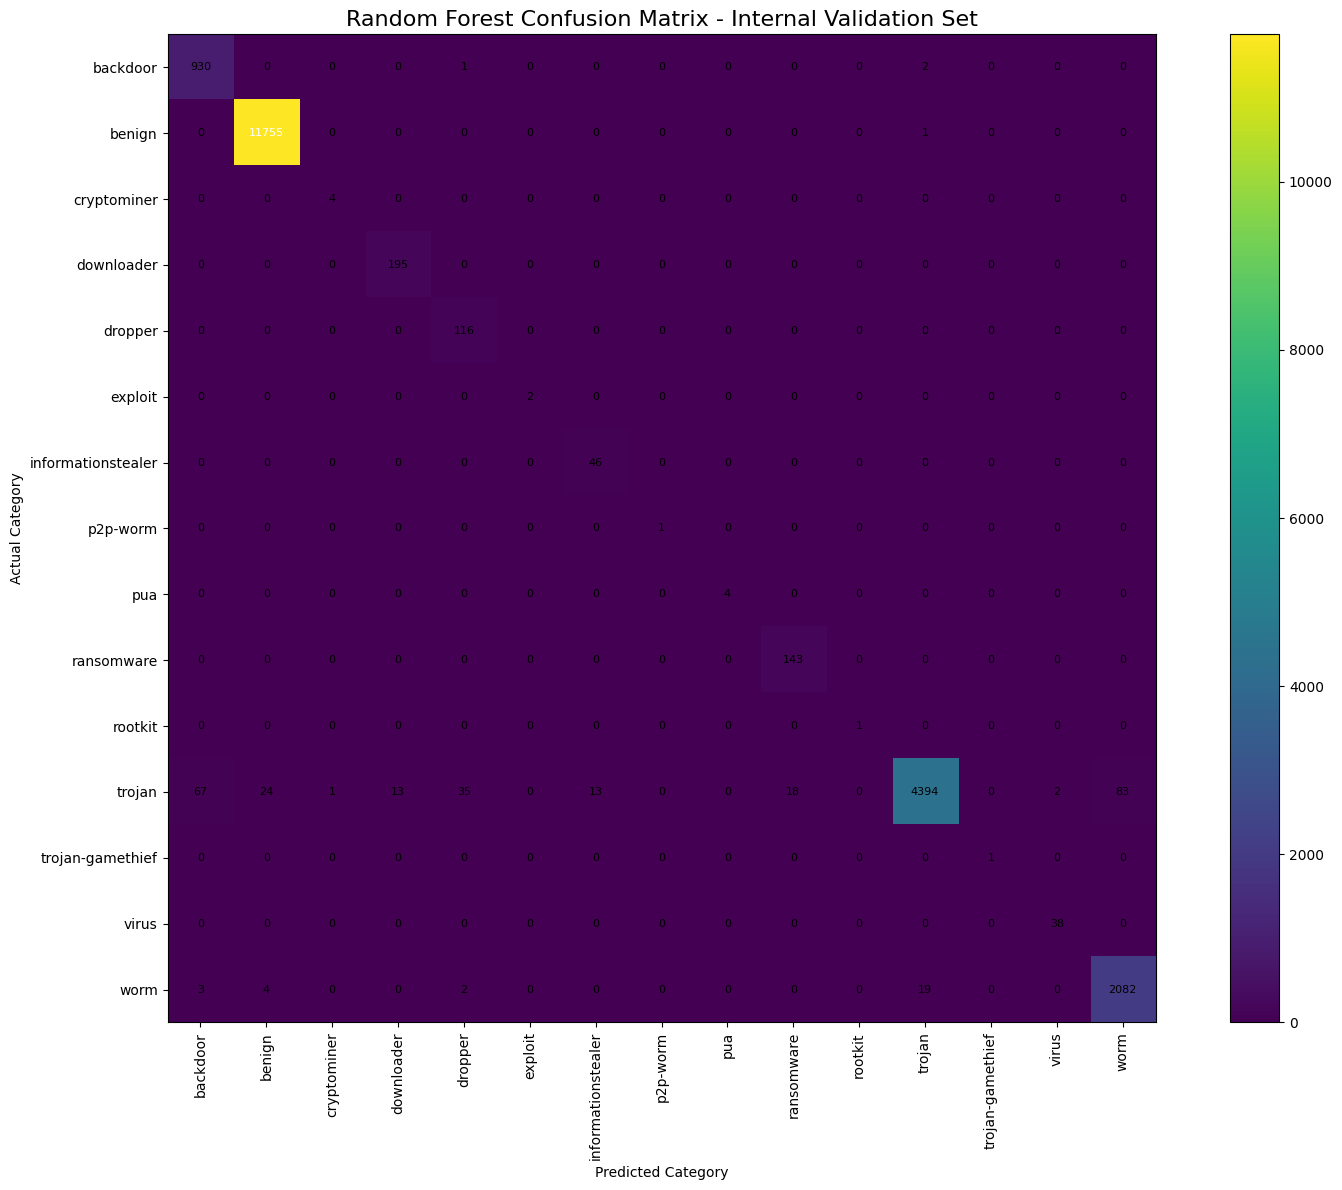

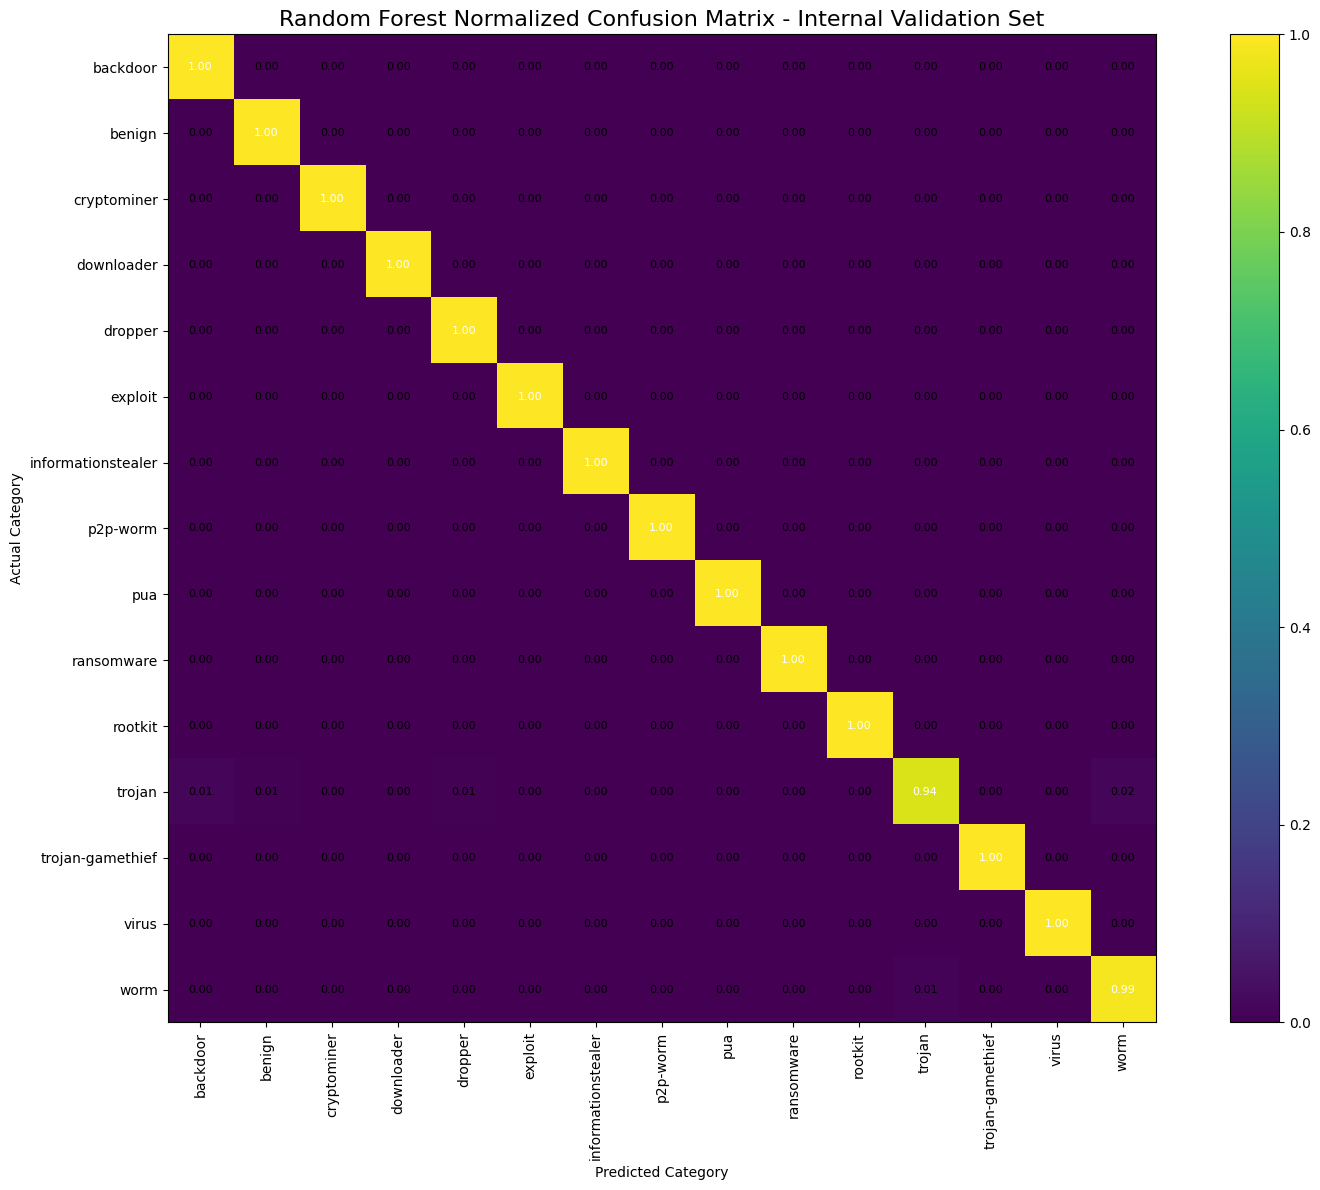

In [ ]:
# ============================================================
# CONFUSION MATRIX IMAGES
# ============================================================

def plot_confusion_matrix_image(y_true, y_pred, title, normalize=False):
    labels = np.arange(len(class_names))

    if normalize:
        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=labels,
            normalize="true"
        )
        fmt = ".2f"
    else:
        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=labels
        )
        fmt = "d"

    plt.figure(figsize=(16, 12))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title, fontsize=16)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=90)
    plt.yticks(tick_marks, class_names)

    threshold = cm.max() / 2

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = format(cm[i, j], fmt)
            plt.text(
                j,
                i,
                value,
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black",
                fontsize=8
            )

    plt.ylabel("Actual Category")
    plt.xlabel("Predicted Category")
    plt.tight_layout()
    plt.show()


# Internal validation confusion matrix
plot_confusion_matrix_image(
    y_test,
    rf_test_results["predictions"],
    "Random Forest Confusion Matrix - Internal Validation Set",
    normalize=False
)

# Normalized internal validation confusion matrix
plot_confusion_matrix_image(
    y_test,
    rf_test_results["predictions"],
    "Random Forest Normalized Confusion Matrix - Internal Validation Set",
    normalize=True
)

## Sample Prediction Check

Predictions on 30 randomly selected samples to verify the end-to-end pipeline - feature input through imputation, variance filtering, and classification - produces correct label outputs.

In [ ]:
# ============================================================
# CHECKING RANDOM FOREST ON OFFICIAL TRAINING SUBSET SAMPLES
# ============================================================

N_SAMPLES = 30
rng = np.random.default_rng(RANDOM_STATE)

sample_indices = rng.choice(X_train_full.shape[0], size=N_SAMPLES, replace=False)

X_sample = X_train_full[sample_indices]
y_sample_true = y_train_full[sample_indices]

rf_sample_pred = rf_final.predict(X_sample)

sample_results = pd.DataFrame({
    "sample_index_in_official_train_subset": sample_indices,
    "sha": df.iloc[sample_indices][metadata_sha_col].values,
    "actual_category": label_encoder.inverse_transform(y_sample_true),
    "predicted_category": label_encoder.inverse_transform(rf_sample_pred),
})

sample_results["correct"] = (
    sample_results["actual_category"] == sample_results["predicted_category"]
)

display(sample_results)

sample_accuracy = accuracy_score(y_sample_true, rf_sample_pred)

print("Random Forest accuracy on selected official training samples:", round(sample_accuracy, 4))
print("Correct predictions:", sample_results["correct"].sum(), "/", N_SAMPLES)

,sample_index_in_official_train_subset,sha,actual_category,predicted_category,correct
0,64383,2ba3a0aa2477f2d2791619210171f8d99b84769efd89aa...,benign,benign,True
1,52637,8fee90e450f46c05140b6977c7303fd7a51caa29d64e99...,benign,benign,True
2,43290,7622fbd0a6f7dadd355dbea5d035fb706cb63cb5313b95...,benign,benign,True
3,85839,0018fd7efe382ad6716cf912d1aada3b193fcdfcbf60c2...,benign,benign,True
4,8922,358ab919eba1ffcfe81ed032053621d1b85ac83cce9d66...,benign,benign,True
5,9415,9939d8537385e5f26f4f08d6819858ca2d51044d92e542...,benign,benign,True
6,18253,f5b40ef73feec5f0420a1025a5c930a823ba2cc67beefb...,backdoor,backdoor,True
7,82274,7bc6f2e70fcc55f07c9a1b4fe8752d9369a8d8ec313f43...,benign,benign,True
8,78595,7b2103a8a24a9af05fec074008a2f6cb6918b235a24ca6...,trojan,trojan,True
9,69721,361812db5d2eb3b137c457a69ab007f5caa0773c88c758...,benign,benign,True


Random Forest accuracy on selected official training samples: 1.0
Correct predictions: 30 / 30


## Holdout Dataset Evaluation

The trained Random Forest model and label encoder are loaded from disk. Holdout labels are prepared using the same SHA256 join and benign-fill logic. An unknown-class check is run before encoding to catch any label mismatches early.

The holdout results represent the model's performance on completely unseen data, giving the most realistic estimate of deployment performance.

RF model: /content/drive/MyDrive/BODMAS_Assignment_Final/Latest_retrain/randomforest/random_forest_model.joblib
Label encoder: /content/drive/MyDrive/BODMAS_Assignment_Final/Latest_retrain/randomforest/label_encoder.joblib
Holdout NPZ: /content/drive/MyDrive/BODMAS_Assignment_Final/Latest_retrain/HoldOutDataSet/bodmas_holdout.npz

Random Forest model loaded.
Classes: ['backdoor', 'benign', 'cryptominer', 'downloader', 'dropper', 'exploit', 'informationstealer', 'p2p-worm', 'pua', 'ransomware', 'rootkit', 'trojan', 'trojan-gamethief', 'virus', 'worm']

Holdout X shape: (34435, 2381)
Holdout metadata shape: (34435, 3)
Holdout category shape: (57293, 2)

Holdout class distribution:


,count
benign,18363
trojan,6724
worm,6145
backdoor,2666
informationstealer,217
dropper,135
ransomware,105
downloader,55
p2p-worm,13
pua,9



Encoded holdout y shape: (34435,)

Running Random Forest on holdout dataset...

RANDOM FOREST HOLDOUT RESULTS
Overall Accuracy: 0.9333
Balanced Accuracy: 0.5581

Classification Report:
                    precision    recall  f1-score   support

          backdoor       0.96      0.94      0.95      2666
            benign       0.94      1.00      0.97     18363
       cryptominer       1.00      1.00      1.00         1
        downloader       0.92      0.60      0.73        55
           dropper       0.49      0.71      0.58       135
           exploit       0.00      0.00      0.00         0
informationstealer       0.95      0.62      0.75       217
          p2p-worm       0.00      0.00      0.00        13
               pua       0.00      0.00      0.00         9
        ransomware       0.75      0.11      0.20       105
           rootkit       0.00      0.00      0.00         0
            trojan       0.91      0.78      0.84      6724
  trojan-gamethief       0.00    

,class,TP,FP,TN,FN,TPR,FPR
0,backdoor,2494,100,31669,172,0.935484,0.003148
1,benign,18357,1253,14819,6,0.999673,0.077962
2,cryptominer,1,0,34434,0,1.000000,0.000000
3,downloader,33,3,34377,22,0.600000,0.000087
4,dropper,96,100,34200,39,0.711111,0.002915
5,exploit,0,0,34435,0,0.000000,0.000000
6,informationstealer,134,7,34211,83,0.617512,0.000205
7,p2p-worm,0,0,34422,13,0.000000,0.000000
8,pua,0,0,34426,9,0.000000,0.000000
9,ransomware,12,4,34326,93,0.114286,0.000117


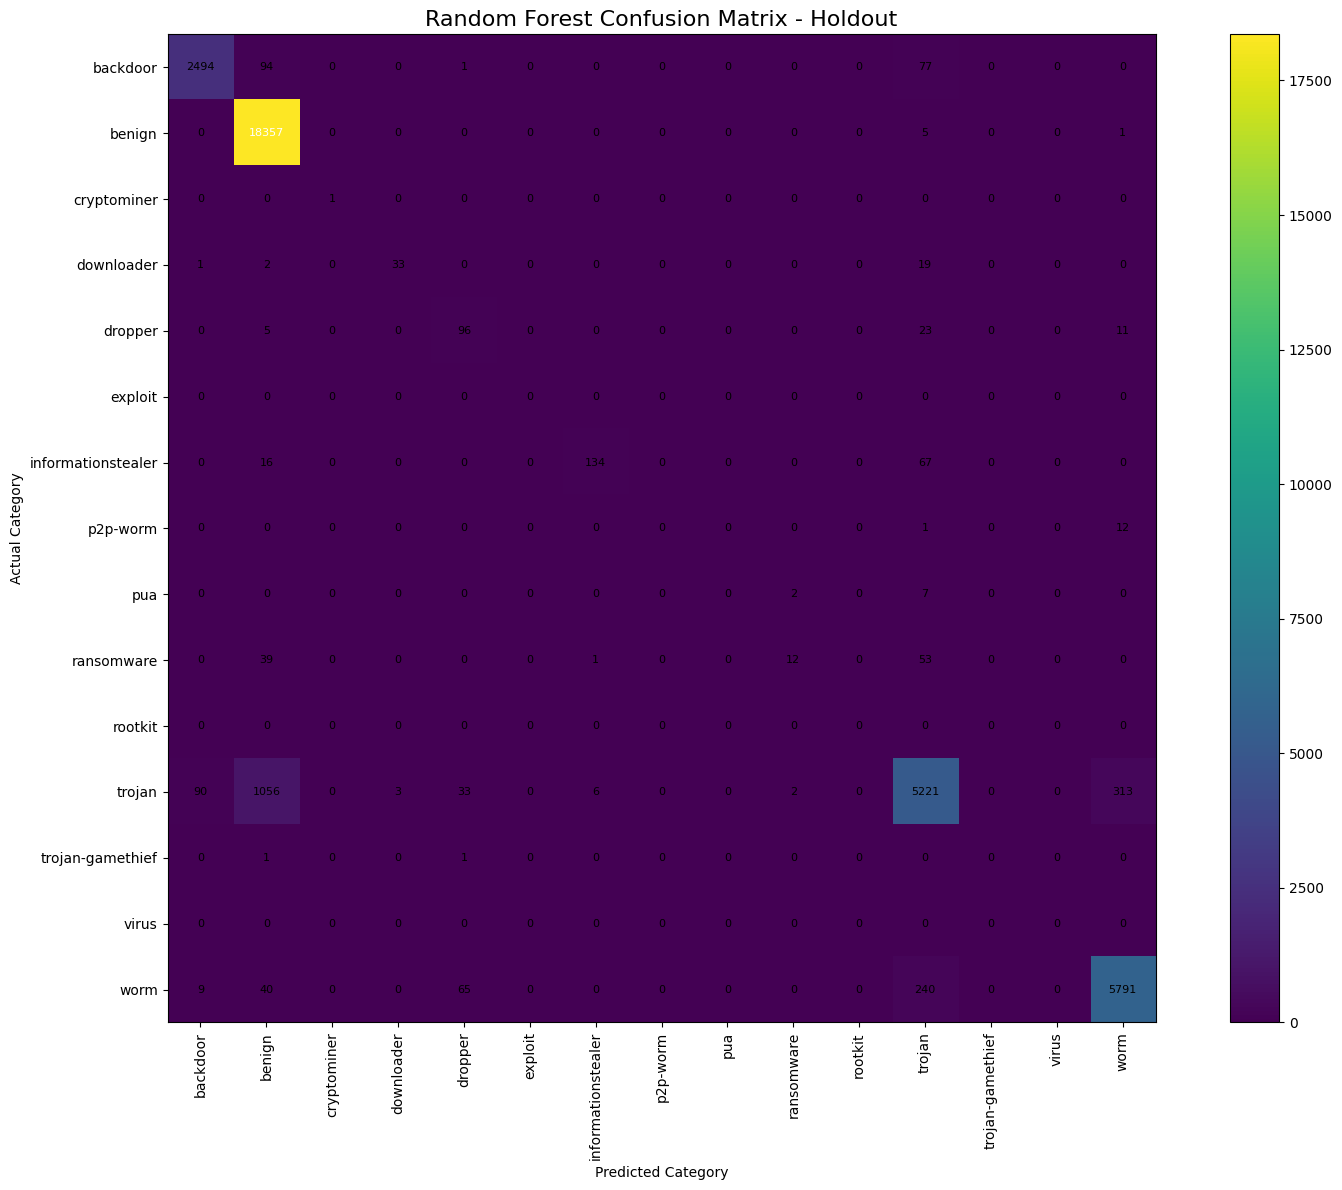

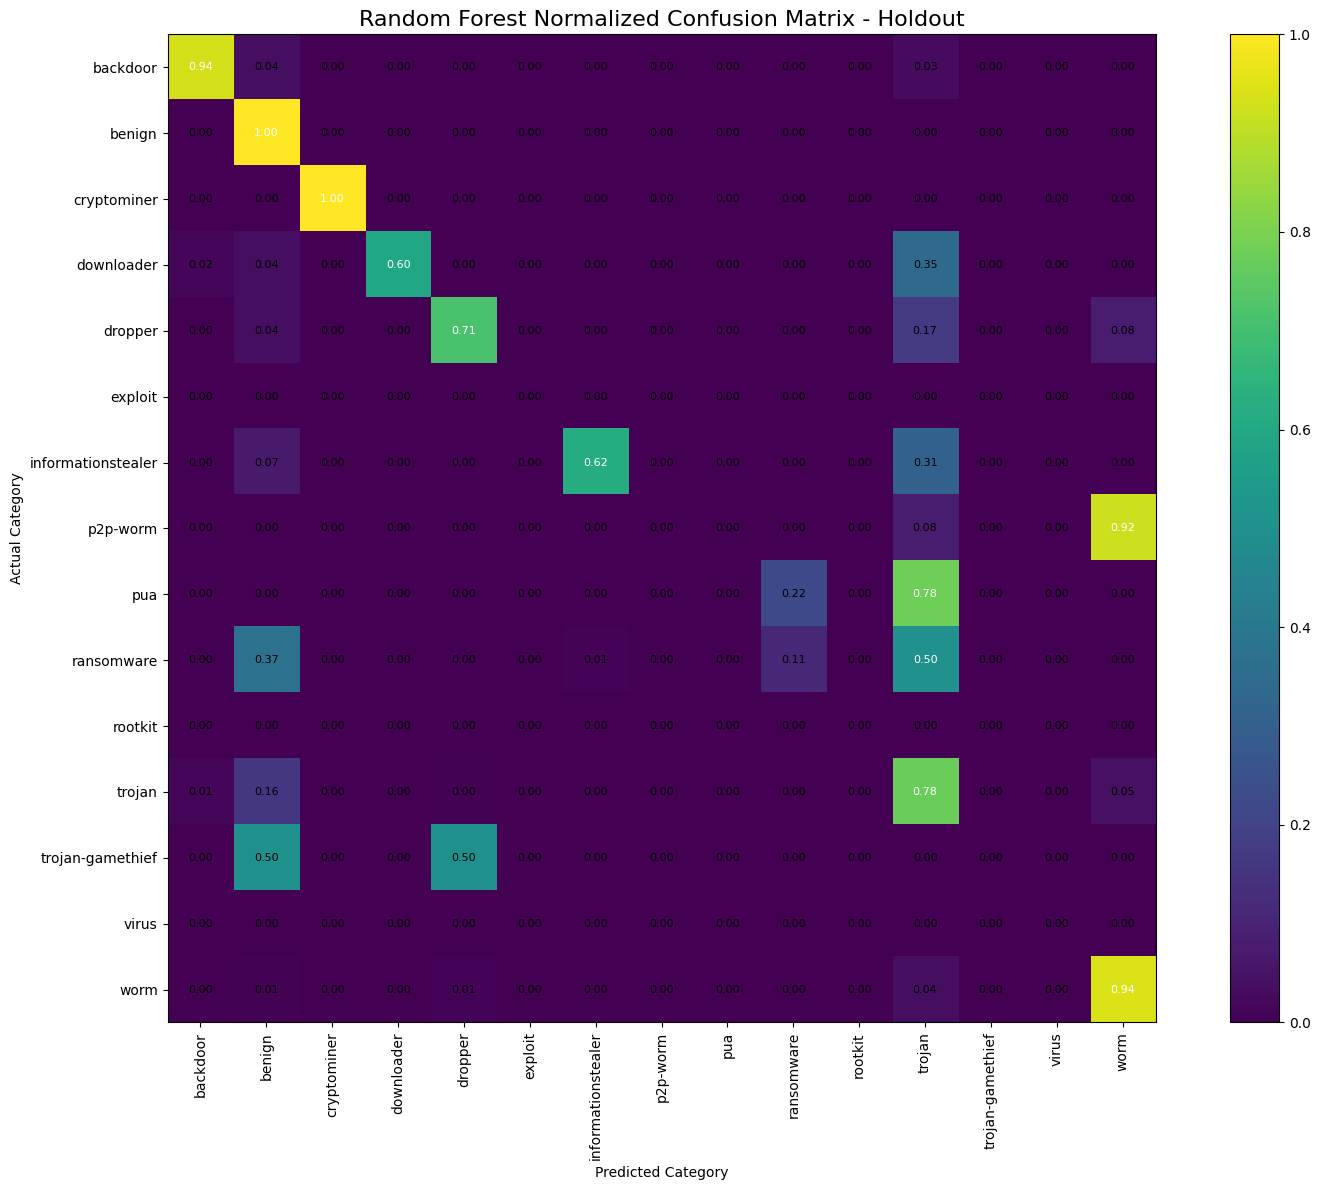

,model,split,trained_on,accuracy,balanced_accuracy
0,Random Forest,official_holdout,official_100000_train_test_subset,0.933324,0.558077


Saved holdout predictions to: /content/drive/MyDrive/BODMAS_Assignment_Final/Latest_retrain/randomforest/rf_holdout_predictions.csv
Saved holdout TPR/FPR to: /content/drive/MyDrive/BODMAS_Assignment_Final/Latest_retrain/randomforest/rf_holdout_tpr_fpr.csv
Saved holdout summary to: /content/drive/MyDrive/BODMAS_Assignment_Final/Latest_retrain/randomforest/rf_holdout_results_summary.csv


In [ ]:
# ============================================================
# RANDOM FOREST - HOLDOUT DATASET EVALUATION
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# PATHS
# ============================================================

PROJECT_DIR = "/content/drive/MyDrive/BODMAS_Assignment_Final/Latest_retrain"

HOLDOUT_DIR = os.path.join(PROJECT_DIR, "HoldOutDataSet")
RF_DIR = os.path.join(PROJECT_DIR, "randomforest")

HOLDOUT_NPZ = os.path.join(HOLDOUT_DIR, "bodmas_holdout.npz")
HOLDOUT_METADATA_CSV = os.path.join(HOLDOUT_DIR, "bodmas_metadata_holdout.csv")
HOLDOUT_CATEGORY_CSV = os.path.join(HOLDOUT_DIR, "bodmas_malware_category.csv")

RF_MODEL_PATH = os.path.join(RF_DIR, "random_forest_model.joblib")
LABEL_ENCODER_PATH = os.path.join(RF_DIR, "label_encoder.joblib")

print("RF model:", RF_MODEL_PATH)
print("Label encoder:", LABEL_ENCODER_PATH)
print("Holdout NPZ:", HOLDOUT_NPZ)

# ============================================================
# LOAD TRAINED RANDOM FOREST MODEL
# ============================================================

rf_model = joblib.load(RF_MODEL_PATH)
label_encoder = joblib.load(LABEL_ENCODER_PATH)

class_names = list(label_encoder.classes_)

print("\nRandom Forest model loaded.")
print("Classes:", class_names)

# ============================================================
# LOAD HOLDOUT DATA
# ============================================================

holdout_data = np.load(HOLDOUT_NPZ, allow_pickle=True)
X_holdout = holdout_data["X"]

holdout_metadata = pd.read_csv(HOLDOUT_METADATA_CSV)
holdout_categories = pd.read_csv(HOLDOUT_CATEGORY_CSV)

print("\nHoldout X shape:", X_holdout.shape)
print("Holdout metadata shape:", holdout_metadata.shape)
print("Holdout category shape:", holdout_categories.shape)

# ============================================================
# PREPARE HOLDOUT CATEGORY LABELS
# ============================================================

metadata_sha_col = "sha256" if "sha256" in holdout_metadata.columns else "sha"
category_sha_col = "sha256" if "sha256" in holdout_categories.columns else "sha"

category_label_col = [
    c for c in holdout_categories.columns
    if c.lower() not in ["sha", "sha256"]
][0]

category_map = holdout_categories.set_index(category_sha_col)[category_label_col]

holdout_df = holdout_metadata.copy()
holdout_df["malware_category"] = holdout_df[metadata_sha_col].map(category_map)

# Missing category means benign
holdout_df["malware_category"] = holdout_df["malware_category"].fillna("benign")

y_holdout_text = holdout_df["malware_category"].astype(str).values

print("\nHoldout class distribution:")
display(pd.Series(y_holdout_text).value_counts())

# Check unknown labels
unknown_classes = set(y_holdout_text) - set(class_names)

if unknown_classes:
    raise ValueError(f"Unknown classes in holdout not seen during training: {unknown_classes}")

y_holdout = label_encoder.transform(y_holdout_text)

print("\nEncoded holdout y shape:", y_holdout.shape)

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def calculate_tpr_fpr(y_true, y_pred, class_names):
    labels = np.arange(len(class_names))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    rows = []

    for i, class_name in enumerate(class_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        rows.append({
            "class": class_name,
            "TP": TP,
            "FP": FP,
            "TN": TN,
            "FN": FN,
            "TPR": TPR,
            "FPR": FPR
        })

    return pd.DataFrame(rows)


def plot_confusion_matrix_image(y_true, y_pred, title, normalize=False):
    labels = np.arange(len(class_names))

    if normalize:
        cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")
        fmt = ".2f"
    else:
        cm = confusion_matrix(y_true, y_pred, labels=labels)
        fmt = "d"

    plt.figure(figsize=(16, 12))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title, fontsize=16)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=90)
    plt.yticks(tick_marks, class_names)

    threshold = cm.max() / 2 if cm.max() > 0 else 0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                format(cm[i, j], fmt),
                ha="center",
                va="center",
                color="white" if cm[i, j] > threshold else "black",
                fontsize=8
            )

    plt.ylabel("Actual Category")
    plt.xlabel("Predicted Category")
    plt.tight_layout()
    plt.show()

# ============================================================
# RANDOM FOREST HOLDOUT PREDICTION
# ============================================================

print("\nRunning Random Forest on holdout dataset...")

rf_pred = rf_model.predict(X_holdout)

rf_accuracy = accuracy_score(y_holdout, rf_pred)
rf_balanced_accuracy = balanced_accuracy_score(y_holdout, rf_pred)

print("\n" + "=" * 80)
print("RANDOM FOREST HOLDOUT RESULTS")
print("=" * 80)

print("Overall Accuracy:", round(rf_accuracy, 4))
print("Balanced Accuracy:", round(rf_balanced_accuracy, 4))

print("\nClassification Report:")
print(classification_report(
    y_holdout,
    rf_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    zero_division=0
))

rf_tpr_fpr = calculate_tpr_fpr(y_holdout, rf_pred, class_names)

print("\nTPR and FPR per class:")
display(rf_tpr_fpr)

# Confusion matrix images
plot_confusion_matrix_image(
    y_holdout,
    rf_pred,
    "Random Forest Confusion Matrix - Holdout",
    normalize=False
)

plot_confusion_matrix_image(
    y_holdout,
    rf_pred,
    "Random Forest Normalized Confusion Matrix - Holdout",
    normalize=True
)


# ============================================================
# SAVING HOLDOUT RESULTS
# ============================================================

holdout_predictions = holdout_df.copy()
holdout_predictions["actual_category"] = label_encoder.inverse_transform(y_holdout)
holdout_predictions["predicted_category"] = label_encoder.inverse_transform(rf_pred)
holdout_predictions["correct"] = holdout_predictions["actual_category"] == holdout_predictions["predicted_category"]

holdout_predictions_path = os.path.join(RF_DIR, "rf_holdout_predictions.csv")
holdout_predictions.to_csv(holdout_predictions_path, index=False)

rf_tpr_fpr_path = os.path.join(RF_DIR, "rf_holdout_tpr_fpr.csv")
rf_tpr_fpr.to_csv(rf_tpr_fpr_path, index=False)

holdout_summary = pd.DataFrame([{
    "model": "Random Forest",
    "split": "official_holdout",
    "trained_on": "official_100000_train_test_subset",
    "accuracy": rf_accuracy,
    "balanced_accuracy": rf_balanced_accuracy
}])

holdout_summary_path = os.path.join(RF_DIR, "rf_holdout_results_summary.csv")
holdout_summary.to_csv(holdout_summary_path, index=False)

display(holdout_summary)

print("Saved holdout predictions to:", holdout_predictions_path)
print("Saved holdout TPR/FPR to:", rf_tpr_fpr_path)
print("Saved holdout summary to:", holdout_summary_path)
